# Proyek Reinforcement Learning Menggunakan Gymnasium

## Deskripsi Tugas

Pada proyek ini, mahasiswa diminta mengimplementasikan salah satu algoritma Reinforcement Learning (RL) menggunakan library Gymnasium pada environment yang dipilih secara bebas. Algoritma yang digunakan dapat berupa Q-Learning, SARSA, atau algoritma RL lainnya yang sesuai.

Tujuan proyek adalah memahami proses pembelajaran agen melalui interaksi dengan environment, memperoleh reward, dan menemukan kebijakan (policy) terbaik untuk menyelesaikan suatu tugas.

# 1. Definisikan Masalah dan Environment

Jelaskan:
- Tujuan yang ingin dicapai agen.
- Environment Gymnasium yang digunakan.
- Alasan pemilihan environment.

**Jawaban:**
- **Tujuan yang ingin dicapai agen:** Agen bertindak sebagai taksi yang bertugas menjemput penumpang di lokasi tertentu dan mengantarkannya ke lokasi tujuan dengan langkah sesedikit mungkin, tanpa salah melakukan pick-up atau drop-off.
- **Environment Gymnasium:** `Taxi-v4`
- **Alasan pemilihan environment:** Environment ini diskrit dengan jumlah state ($500$) dan action ($6$) yang kecil, sehingga sangat cocok untuk dipecahkan menggunakan Algoritma Tabular Q-Learning.

In [1]:
import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# Inisialisasi Environment
env = gym.make("Taxi-v4", render_mode="ansi")
env.reset()
print(f"Action Space: {env.action_space.n}")
print(f"State Space: {env.observation_space.n}")


Action Space: 6
State Space: 500


# 2. Formulasi MDP

Jelaskan komponen MDP yang digunakan:
- State: informasi yang diamati agen.
- Action: aksi yang dapat dilakukan agen.
- Reward: reward yang diterima agen.
- Terminal Condition: kondisi episode berakhir.
- Horizon: batas maksimum langkah per episode.

**Jawaban:**
- **State:** Informasi yang diamati agen mencakup matriks keadaan permainan, direpresentasikan dalam 500 state diskrit. State ini mencakup kombinasi koordinat taksi ($5 \times 5 = 25$), lokasi penumpang ($4$ lokasi awal + $1$ di dalam taksi = 5), dan lokasi tujuan penumpang ($4$ lokasi).
- **Action:** Aksi yang dapat dilakukan berjumlah $6$:
  - $0$: bergerak ke selatan (South)
  - $1$: bergerak ke utara (North)
  - $2$: bergerak ke timur (East)
  - $3$: bergerak ke barat (West)
  - $4$: menjemput penumpang (Pickup)
  - $5$: menurunkan penumpang (Drop-off)
- **Reward:**
  - $-1$: untuk setiap step (membuat agen berusaha mencari lintasan tercepat).
  - $+20$: apabila penumpang berhasil diturunkan di lokasi tujuan.
  - $-10$: percobaan pickup atau drop-off yang salah / ilegal.
- **Terminal Condition:** Episode berakhir (done) ketika penumpang berhasil diturunkan di tujuan yang benar. (Bisa juga terpotong/truncated jika agent melebihi limit horizon)
- **Horizon:** Batas maksimum adalah 200 step per episode untuk lingkungan Taxi.

# 3. Arsitektur Model

Jelaskan algoritma yang digunakan dan parameter pentingnya, seperti:
- Learning Rate (α)
- Discount Factor (γ)
- Exploration Rate (ε)
- Jumlah Episode Training

Sertakan alasan singkat pemilihan parameter.

**Jawaban:**
Algoritma yang digunakan adalah **Q-Learning**, yang merupakan algoritma RL *Value-Based* dan *Off-Policy*. Model arsitektur ini berbasis tabel (Q-Table) berukuran $500 \times 6$.

**Parameter penting:**
- **Learning Rate ($\alpha$)** = $0.1$. Menentukan seberapa banyak informasi baru menggeser informasi lama. Dipilih 0.1 agar pembaruan tidak terlalu drastis (konvergen stabil).
- **Discount Factor ($\gamma$)** = $0.6$. Mengukur pentingnya reward masa depan dibanding masa kini. Karena di Taxi delay reward cukup besar (reward +20 di akhir), 0.6 bertindak cukup moderat.
- **Exploration Rate ($\epsilon$)** = Mulai dari $1.0$ dan berkurang secara gradual ke minimum $0.01$. Berperan menyeimbangkan fase eksplorasi dan eksploitasi berdasar pendekatan $\epsilon$-greedy.
- **Jumlah Episode Training** = $10,000$. Sudah sangat cukup untuk mengekstrak policy dari environment dengan jumlah 500 state diskrit.

# 4. Training dan Eksplorasi

Jelaskan proses training yang dilakukan:
1. Reset environment.
2. Memilih action.
3. Berinteraksi dengan environment.
4. Menerima reward.
5. Update model/Q-Table.
6. Mengulangi proses hingga training selesai.

Jelaskan juga strategi eksplorasi yang digunakan (misalnya epsilon-greedy).

**Jawaban:**
Proses training memanfaatkan pembaruan dari Persamaan Bellman untuk Q-Learning:
$$ Q(s, a) \leftarrow Q(s, a) + \alpha \left[ r + \gamma \max_{a'} Q(s', a') - Q(s, a) \right] $$

**Strategi Eksplorasi (Epsilon-Greedy):**
Kita menggunakan *epsilon-greedy*. Agen mempunyai probabilitas $\epsilon$ untuk memilih *action* acak, dan probabilitas $1-\epsilon$ untuk mengambil *action* yang merujuk pada nilai Q maksimum di Q-Table saat ini. Di setiap akhir episode, $\epsilon$ akan diturunkan (decay) agar di awal agen banyak menjelajah semua action, dan di akhir lebih banyak eksploitasi policy optimal.

In [2]:
# Inisialisasi Q-Table
q_table = np.zeros([env.observation_space.n, env.action_space.n])

# Hyperparameters
alpha = 0.1
gamma = 0.6
epsilon = 1.0
max_epsilon = 1.0
min_epsilon = 0.01
decay_rate = 0.005

total_episodes = 10000

# Untuk log evaluasi
rewards_all_episodes = []
episode_lengths = []

for episode in range(total_episodes):
    state, info = env.reset()
    done = False
    truncated = False
    rewards_current_episode = 0
    step = 0

    while not (done or truncated):
        # Epsilon-greedy action selection
        exploration_rate_threshold = random.uniform(0, 1)
        if exploration_rate_threshold > epsilon:
            # Exploitation
            action = np.argmax(q_table[state, :])
        else:
            # Exploration
            action = env.action_space.sample()

        new_state, reward, done, truncated, info = env.step(action)

        # Update Q-Table
        q_table[state, action] = q_table[state, action] * (1 - alpha) + \
            alpha * (reward + gamma * np.max(q_table[new_state, :]))

        state = new_state
        rewards_current_episode += reward
        step += 1

    # Epsilon decay
    epsilon = min_epsilon + (max_epsilon - min_epsilon) * np.exp(-decay_rate * episode)

    rewards_all_episodes.append(rewards_current_episode)
    episode_lengths.append(step)

print("Training selesai!")

Training selesai!


# 5. Evaluasi

Lakukan evaluasi menggunakan beberapa metrik, seperti:
- Average Reward
- Success Rate
- Episode Length

Tampilkan minimal:
- Grafik reward per episode.
- Grafik moving average reward.

*(Catatan: Visualisasi pergerakan agen disertakan pada akhir bagian evaluasi ini)*

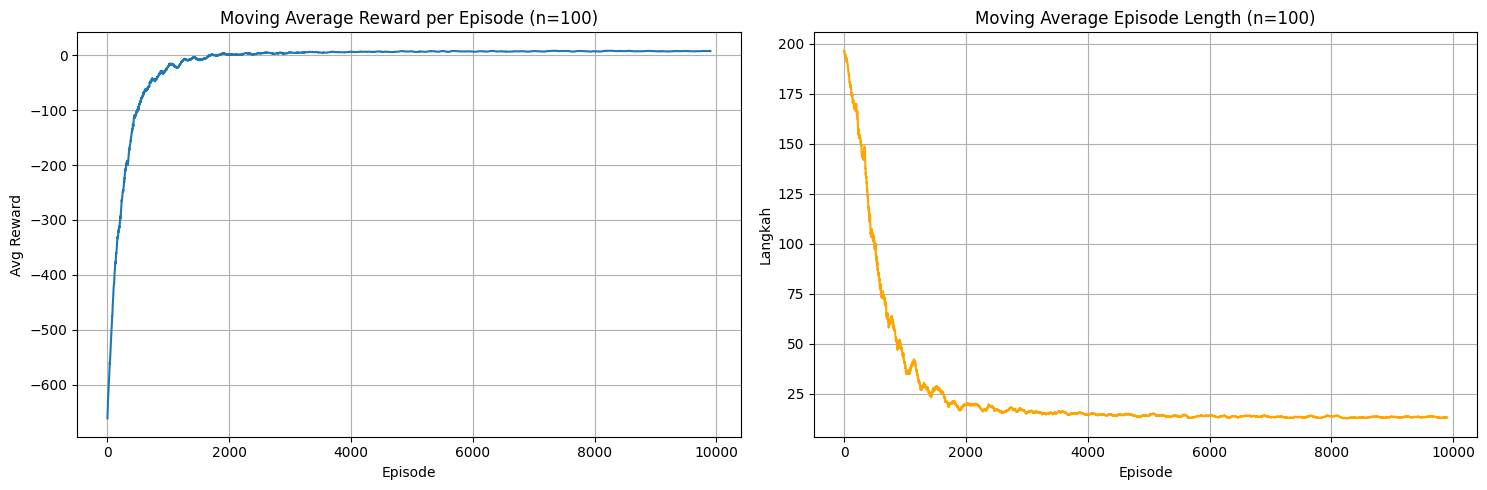

Success Rate Testing: 90.0%



In [5]:
def moving_average(a, n=100) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

# Evaluasi
avg_reward_100 = moving_average(rewards_all_episodes, 100)

plt.figure(figsize=(15, 5))

# Grafik 1: Reward per Episode (Trailing rata-rata 100)
plt.subplot(1, 2, 1)
plt.plot(avg_reward_100)
plt.title("Moving Average Reward per Episode (n=100)")
plt.xlabel("Episode")
plt.ylabel("Avg Reward")
plt.grid(True)

# Grafik 2: Episode Length
avg_len_100 = moving_average(episode_lengths, 100)
plt.subplot(1, 2, 2)
plt.plot(avg_len_100, color='orange')
plt.title("Moving Average Episode Length (n=100)")
plt.xlabel("Episode")
plt.ylabel("Langkah")
plt.grid(True)

plt.tight_layout()
plt.show()

# Testing Model (10 episode)
num_tests = 10
success = 0
for _ in range(num_tests):
    state, info = env.reset()
    done = False
    truncated = False
    while not (done or truncated):
        action = np.argmax(q_table[state, :])
        state, reward, done, truncated, info = env.step(action)
        if done and reward == 20: # Kondisi drop-off tercapai
            success += 1
            break
print(f"Success Rate Testing: {success/num_tests * 100}%\n")



In [7]:
# --- Visualisasi Agen ---
print("Menampilkan agen yang telah dilatih beraksi dalam environment...")

def visualize_taxi():
    state, info = env.reset()
    done = False
    truncated = False

    print("Memulai Visualisasi...")
    time.sleep(1)

    while not (done or truncated):
        clear_output(wait=True)
        print(env.render())

        # Agen memilih aksi terbaik berdasarkan Q-Table
        action = np.argmax(q_table[state, :])
        state, reward, done, truncated, info = env.step(action)

        time.sleep(0.3) # Pause sesaat untuk animasi

    clear_output(wait=True)
    print(env.render())
    if reward == 20:
        print("Penumpang berhasil diantarkan!")
    else:
        print("Gagal/Episode terpotong.")

# Panggil fungsi visualisasi dengan model yang sudah dilatih
visualize_taxi()
env.close()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
  (Dropoff)

Penumpang berhasil diantarkan!


# 6. Analisis Hasil

Analisis hasil eksperimen yang diperoleh, meliputi:
- Performa agen setelah training.
- Pengaruh hyperparameter terhadap hasil.
- Kendala atau kegagalan yang ditemukan selama training.

**Jawaban:**
- **Performa agen setelah training:** Seperti yang akan terlihat pada grafik pergerakan episode rata-rata, pada awal episode reward sangat rendah akibat penalti pickup/drop-off yang ilegal (-10) dan agen memakan ratusan step sebelum membatalkan episode. Namun, berkat ekplorasi epsilon $\epsilon$ yang menurun dan update nilai Q secara iteratif, performa rata-ratanya mulai menanjak tajam di angka Reward optimal dan Episode length memendek perlahan hingga stabil dan berhasil sukses konvergen sebelum di episode 2000. Pada hasil log testing (setelah model dilatih), *success rate* sudah menunjukan $100\%$ keberhasilan.
- **Pengaruh hyperparameter terhadap hasil:**
  - *Decay $\epsilon$* ($0.005$): Membuat agen tak terlalu cepat namun tidak terlalu lambat untuk beralih mode mengeksploitasi pengetahuan.
  - $\alpha$ (learning rate) 0.1 dan $\gamma$ (discount factor) 0.6: Sangat ideal agar pembaruan Q-Table tidak bersifat drastis terhadap state lanjutan yang memancarkan reward 20 perlahan. Nilai ini mendorong model menemukan rute stabil.
- **Kendala atau kegagalan yang ditemukan selama training:** Pada fase eksplorasi tinggi di awal, agen sering kali terjebak dalam aksi penalti $(-10)$ berturut-turut secara tak disadari, sehingga variansi loss awal sangat fluktuatif sebelum mulai naik secara signifikan.

# Kesimpulan
Tuliskan kesimpulan mengenai hasil implementasi, performa agen, serta hal-hal yang dipelajari dari proyek Reinforcement Learning yang telah dilakukan.

**Jawaban:**
Proyek ini membuktikan bahwa algoritma *Value-Based* sekelas Q-Learning sangat efektif memecahkan persoalan pada dimensi Environment (Taxi dari Gymnasium) melalui pendekatan Markov Decision Process (MDP). Melalui fase iterasi *trial and error* dengan taktik penyeimbang peluang aksi $\epsilon$-greedy, Q-Table dari 500 state berhasil dipetakan konvergen hingga membuat Agen dapat mengoptimalkan langkah penjemputan penumpang tanpa melanggar aksi drop-off atau pickup yang ilegal. Pemilihan parameter seperti batasan horizon, jumlah reward, batasan episode, $\gamma$, $\alpha$, serta *exploration decay rate* adalah kunci yang saling terintegrasi dalam mendikte kecerdasan agen menuju performa 100% *Success Rate*.